In [1]:
import pandas as pd
csv_path = '/home/daniel.lien/dev/homework/data/cleaned_copd_data.csv'
df = pd.read_csv(csv_path)
df.head()


,YearStart,LocationDesc,Topic,Question,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1,GeoLocation,QuestionID,StratificationCategoryID1,StratificationID1
0,2014,Alaska,Chronic Obstructive Pulmonary Disease,Mortality with chronic obstructive pulmonary d...,Number,Number,89.0,Gender,Male,POINT (-147.72205903599973 64.84507995700051),COPD1_1,GENDER,GENM
1,2020,Alabama,Chronic Obstructive Pulmonary Disease,Mortality with chronic obstructive pulmonary d...,Number,Number,3346.0,Overall,Overall,POINT (-86.63186076199969 32.84057112200048),COPD1_1,OVERALL,OVR
2,2012,Alabama,Chronic Obstructive Pulmonary Disease,Mortality with chronic obstructive pulmonary d...,Number,Number,252.0,Race/Ethnicity,"Black, non-Hispanic",POINT (-86.63186076199969 32.84057112200048),COPD1_1,RACE,BLK
3,2015,Alabama,Chronic Obstructive Pulmonary Disease,Mortality with chronic obstructive pulmonary d...,Number,Number,1617.0,Gender,Male,POINT (-86.63186076199969 32.84057112200048),COPD1_1,GENDER,GENM
4,2017,Alabama,Chronic Obstructive Pulmonary Disease,Mortality with chronic obstructive pulmonary d...,Number,Number,348.0,Race/Ethnicity,"Black, non-Hispanic",POINT (-86.63186076199969 32.84057112200048),COPD1_1,RACE,BLK


In [2]:
df.shape

(143586, 13)

In [5]:
# Filter for only COPD1_1 12497 / 143586 
df = df[df['QuestionID'] == 'COPD1_1']
df.shape

(13497, 13)

In [7]:
# Drop Columns from entire dataset that are missing = Num of missing values == num of rows --> Completely empty
df = df.drop(columns=[
            'Topic',
            'Question',
            'GeoLocation'
        ])
print(df.shape)

(13497, 10)


In [8]:
df.head()

,YearStart,LocationDesc,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1,QuestionID,StratificationCategoryID1,StratificationID1
0,2014,Alaska,NaN,Number,89.0,Gender,Male,COPD1_1,GENDER,GENM
1,2020,Alabama,NaN,Number,3346.0,Overall,Overall,COPD1_1,OVERALL,OVR
2,2012,Alabama,NaN,Number,252.0,Race/Ethnicity,"Black, non-Hispanic",COPD1_1,RACE,BLK
3,2015,Alabama,NaN,Number,1617.0,Gender,Male,COPD1_1,GENDER,GENM
4,2017,Alabama,NaN,Number,348.0,Race/Ethnicity,"Black, non-Hispanic",COPD1_1,RACE,BLK


In [ ]:
# drop both Stratificaiton IDs
#combine stratification into one columne for grouping 
df = df.drop(columns=['StratificationCategoryID1', 'StratificationID1'])
df['StratificationCombined'] = df['StratificationCategory1'] + "_" + df['Stratification1']



In [13]:
df = df.drop(columns=['StratificationCategory1', 'Stratification1'])


In [15]:
df = df[df['DataValueType'] == 'Number']

In [16]:
df.isnull().sum() # confirmed that Data Value Unit is missing when the Data Value Type is 'Number'
#There are still some missing values 

YearStart                    0
LocationDesc                 0
DataValueUnit             4499
DataValueType                0
DataValue                 1365
QuestionID                   0
StratificationCombined       0
dtype: int64

In [19]:
df.head()

,YearStart,LocationDesc,DataValueUnit,DataValueType,DataValue,QuestionID,StratificationCombined
0,2014,Alaska,NaN,Number,89.0,COPD1_1,Gender_Male
1,2020,Alabama,NaN,Number,3346.0,COPD1_1,Overall_Overall
2,2012,Alabama,NaN,Number,252.0,COPD1_1,"Race/Ethnicity_Black, non-Hispanic"
3,2015,Alabama,NaN,Number,1617.0,COPD1_1,Gender_Male
4,2017,Alabama,NaN,Number,348.0,COPD1_1,"Race/Ethnicity_Black, non-Hispanic"


In [21]:
df = df.dropna(subset=['DataValue'])

In [23]:
df = df.drop(columns=['DataValueUnit'])


In [24]:
df.isnull().sum()

YearStart                 0
LocationDesc              0
DataValueType             0
DataValue                 0
QuestionID                0
StratificationCombined    0
dtype: int64

In [25]:
# save to csv
output_dir = '/home/daniel.lien/dev/homework/data/Single_Questions/COPD1_1.csv'
df.to_csv(output_dir, index=False)

EDA on COPD1_1

In [29]:
# Summary statistics for the 'DataValue' column
print(df['DataValue'].describe())

# Check the distribution of 'DataValueType'
print(df['DataValueType'].value_counts())

# Count unique values for 'YearStart', 'LocationDesc', and 'StratificationCombined'
print(df['YearStart'].value_counts())
print(df['LocationDesc'].value_counts())
print(df['StratificationCombined'].value_counts())

count     3068.000000
mean      1563.080508
std       2002.071053
min         20.000000
25%        221.000000
50%        846.000000
75%       2137.750000
max      13317.000000
Name: DataValue, dtype: float64
DataValueType
Number    3068
Name: count, dtype: int64
YearStart
2018    289
2020    288
2019    286
2017    285
2016    282
2015    280
2014    276
2013    274
2012    270
2011    270
2010    268
Name: count, dtype: int64
LocationDesc
California        88
Washington        87
Arizona           84
Florida           81
Texas             78
New York          77
Illinois          77
Michigan          77
New Jersey        77
Nevada            76
Pennsylvania      72
Massachusetts     72
North Carolina    70
Colorado          69
Oklahoma          69
Ohio              67
Georgia           67
Virginia          65
Connecticut       65
Kansas            64
Minnesota         63
Wisconsin         63
Indiana           59
Oregon            58
New Mexico        58
Hawaii            57
Maryland  

Data Value (Number) vs Year Start

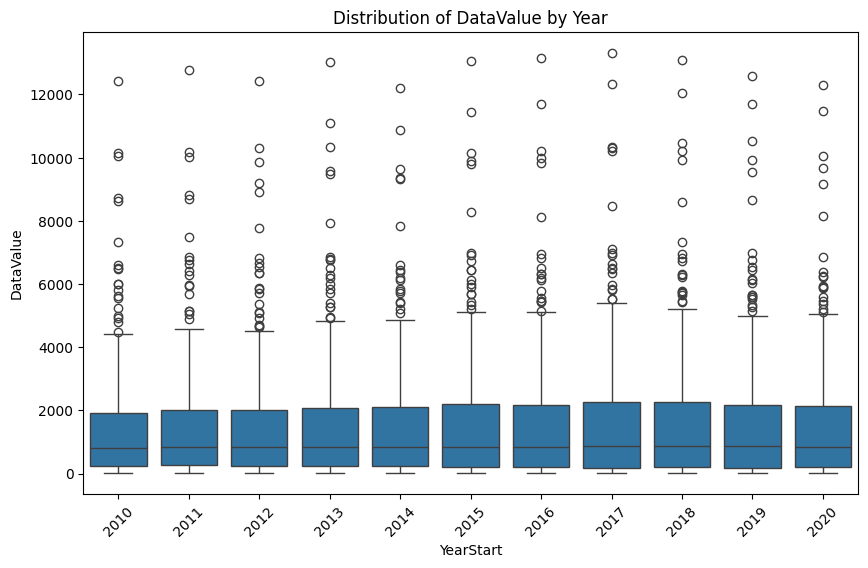

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot DataValue by YearStart
plt.figure(figsize=(10, 6))
sns.boxplot(x='YearStart', y='DataValue', data=df)
plt.title('Distribution of DataValue by Year')
plt.xticks(rotation=45)
plt.show()


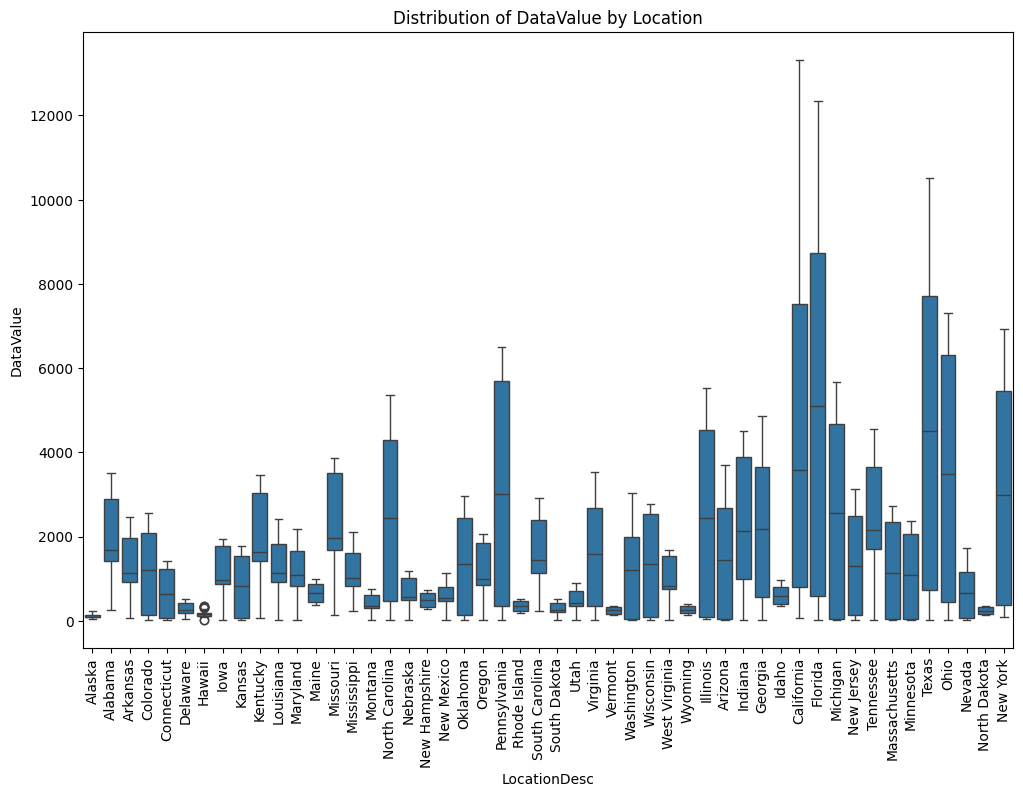

In [32]:
# Plot DataValue by LocationDesc
plt.figure(figsize=(12, 8))
sns.boxplot(x='LocationDesc', y='DataValue', data=df)
plt.title('Distribution of DataValue by Location')
plt.xticks(rotation=90)
plt.show()


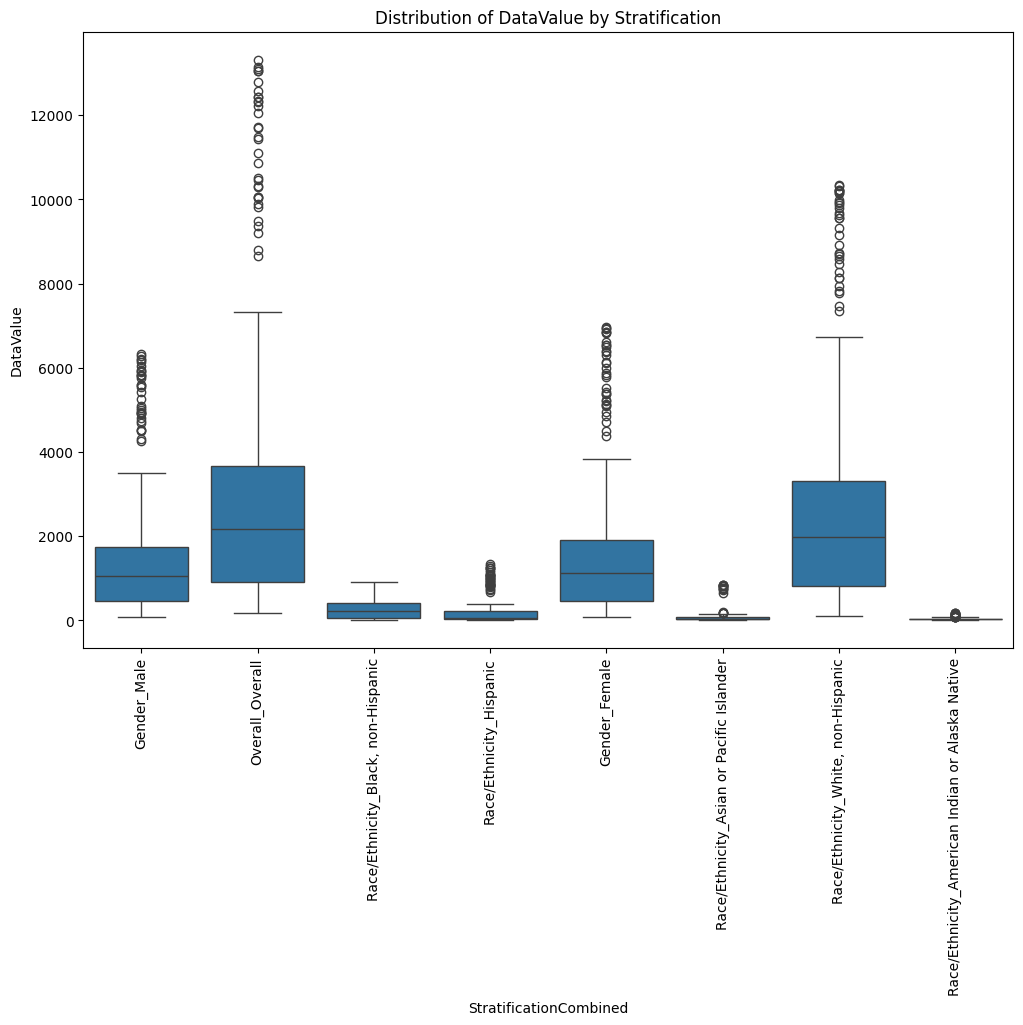

In [34]:
# Plot DataValue by StratificationCombined
plt.figure(figsize=(12, 8))
sns.boxplot(x='StratificationCombined', y='DataValue', data=df)
plt.title('Distribution of DataValue by Stratification')
plt.xticks(rotation=90)
plt.show()


In [37]:
# Filter for Gender and Race/Ethnicity stratifications in StratificationCombined
gender_data = df[df['StratificationCombined'].str.contains('Gender')]
race_ethnicity_data = df[df['StratificationCombined'].str.contains('Race/Ethnicity')]

# Check the distribution of gender and race/ethnicity stratifications
print(gender_data['StratificationCombined'].value_counts())
print(race_ethnicity_data['StratificationCombined'].value_counts())

StratificationCombined
Gender_Male      550
Gender_Female    550
Name: count, dtype: int64
StratificationCombined
Race/Ethnicity_White, non-Hispanic                 550
Race/Ethnicity_Black, non-Hispanic                 389
Race/Ethnicity_Hispanic                            211
Race/Ethnicity_Asian or Pacific Islander           140
Race/Ethnicity_American Indian or Alaska Native    128
Name: count, dtype: int64


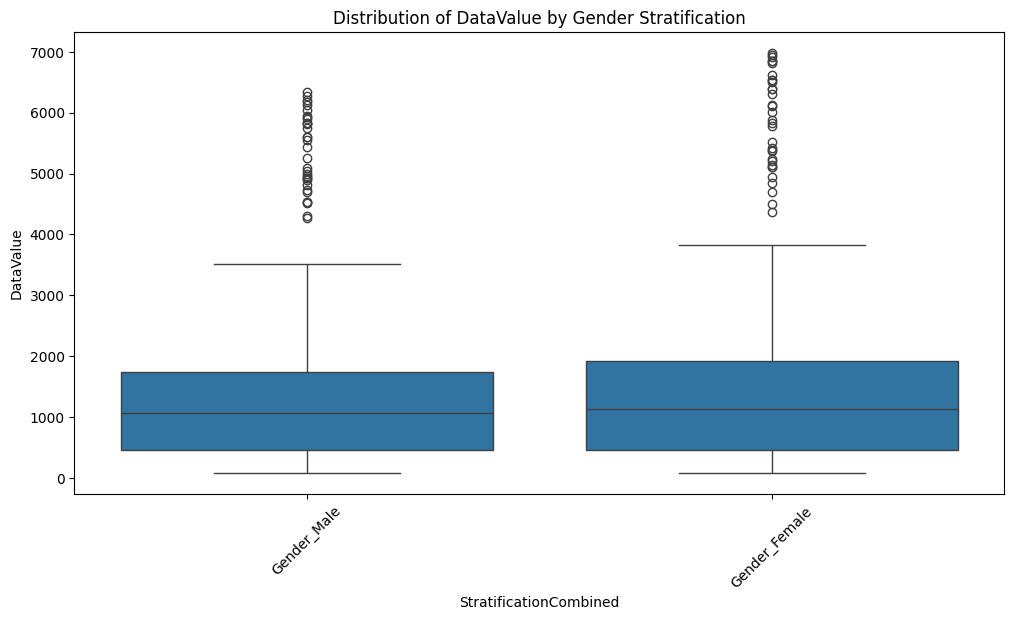

In [38]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='StratificationCombined', y='DataValue', data=gender_data)
plt.title('Distribution of DataValue by Gender Stratification')
plt.xticks(rotation=45)
plt.show()


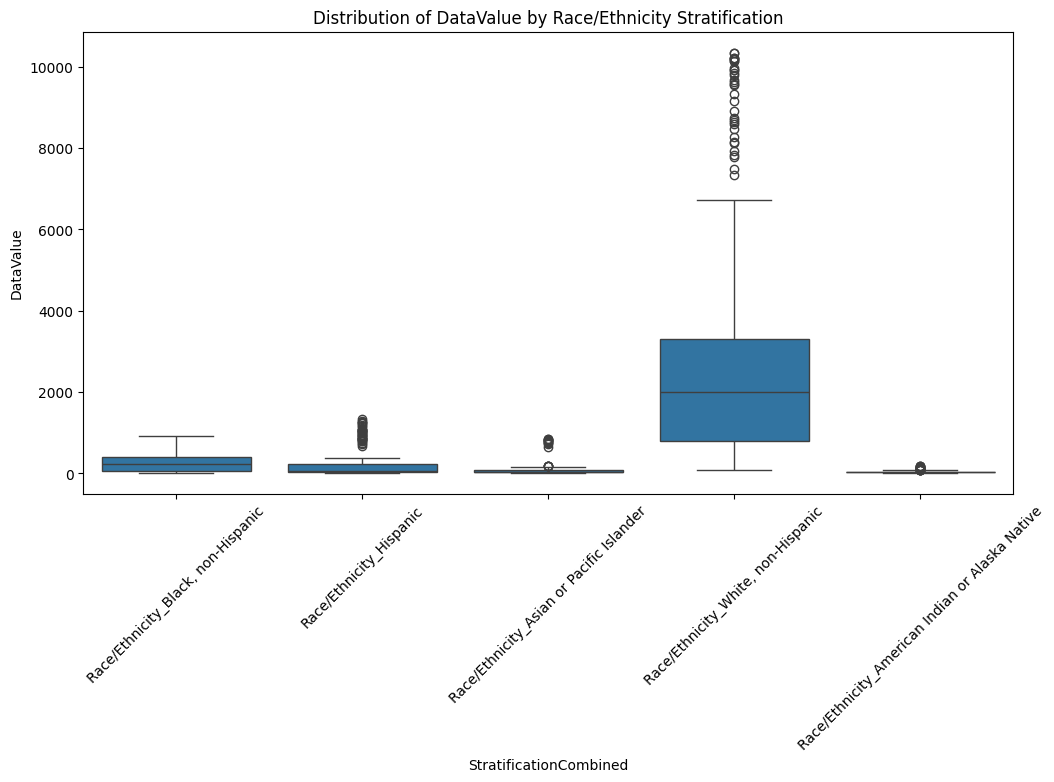

In [39]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='StratificationCombined', y='DataValue', data=race_ethnicity_data)
plt.title('Distribution of DataValue by Race/Ethnicity Stratification')
plt.xticks(rotation=45)
plt.show()


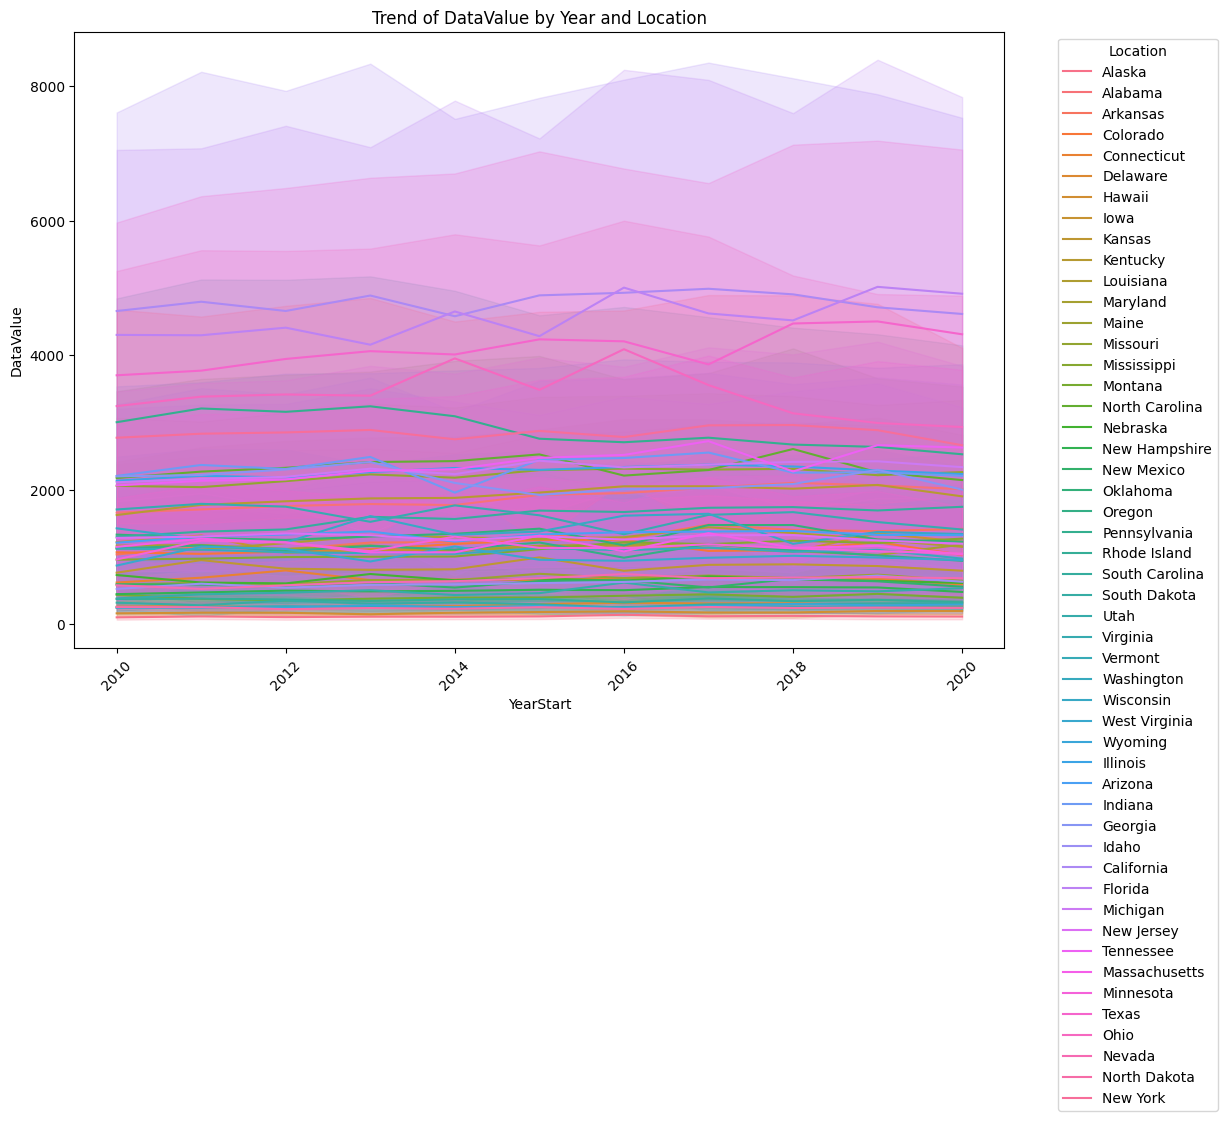

In [35]:
# Visualizing the trend of DataValue over YearStart by LocationDesc
plt.figure(figsize=(12, 8))
sns.lineplot(x='YearStart', y='DataValue', hue='LocationDesc', data=df, markers=True)
plt.title('Trend of DataValue by Year and Location')
plt.xticks(rotation=45)
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
